In [1]:
from getpass import getuser # Libaray to copy things
from pathlib import Path # Object oriented libary to deal with paths
import os
from tempfile import NamedTemporaryFile, TemporaryDirectory # Creating temporary Files/Dirs
from subprocess import run, PIPE
import sys
 
import dask # Distributed data libary
from dask_jobqueue import SLURMCluster # Setting up distributed memories via slurm
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import xarray as xr # Libary to work with labeled n-dimensional data and dask

In [2]:
# Set some user specific variables
scratch_dir = Path('/scratch') / getuser()[0] / getuser() # Define the users scratch dir
# Create a temp directory where the output of distributed cluster will be written to, after this notebook
# is closed the temp directory will be closed
dask_tmp_dir = TemporaryDirectory(dir=scratch_dir, prefix='PostProc')
cluster = SLURMCluster(memory='400GiB',
                       cores=72,
                       project='mh0731',
                       walltime='1:00:00',
                       queue='compute',
                       name='PostProc',
                   #    scheduler_options={'dashboard_address': ':12435'},
                       local_directory=dask_tmp_dir.name,
                       job_extra=[f'-J PostProc', 
                                  f'-D {dask_tmp_dir.name}',
                                  f'--begin=now',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o',
                                  f'--output={dask_tmp_dir.name}/LOG_cluster.%j.o'
                                 ],
                       interface='ib0')
cluster.scale(jobs=1)
dask_client = Client(cluster)

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/dask_jobqueue/slurm.py:55: FutureWarning: project has been renamed to account as this kwarg was used wit -A option. You are still using it (please also check config files). If you did not set account yet, project will be respected for now, but it will be removed in a future release. If you already set account, project is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/home/m/m300948/.conda/envs/precippuzzle/lib/p

In [3]:
def contourf(data, vmin, vmax, cmap, levels, extend, title):
    fig = plt.figure(figsize=[8,10],facecolor='w')
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

    ax.set_extent([-80,-40,-19,10])
    ax.coastlines('50m',linewidth=0.8)
    gl = ax.gridlines(draw_labels=True, linewidth=1.5, color='gray',
                    xlocs=range(-180,180,20), ylocs=range(-90,90,10), crs=ccrs.PlateCarree())
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style, gl.ylabel_style = {'fontsize': 25}, {'fontsize': 25}
    # manipulate `gridliner` object
    gl.xlabels_top = False
    gl.ylabels_left = False
    gl.xlines = False
    gl.ylines = False

    # define lat and lon
    lats = data.lat
    lons = data.lon

    # Apply the same threshold to both datasets (pr_ctl_mm_hour_mask_q99_counts)
    #m = data.sum('hour').plot(levels=np.linspace(0, 20, 10), extend='max', cmap='YlGnBu', transform=ccrs.PlateCarree())
    #m = ax.pcolormesh(lons,lats,data.sum('hour'),cmap=cmap,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
    m = ax.pcolormesh(lons,lats,data,cmap=cmap,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())

    #ax.clabel(a, inline=True, fontsize=20)
    #ax.clabel(b, inline=True, fontsize=20)

    kw = {'levels':[-1], 'colors':['lightgrey'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                    ax=ax,
                    transform=ccrs.PlateCarree(),
                    **kw
                    )
    bounds = np.linspace(vmin, vmax, levels)
    cb = plt.colorbar(m, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend,ticks=bounds, boundaries=bounds)
    cb.ax.tick_params(labelsize=25)
    cb.ax.set_xticklabels(bounds,rotation=270)
    plt.title(title, fontsize='20')
    plt.show()

In [6]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

# calculation
#import metpy.calc as mpcalc

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data
import glob
import os

#metpy
#import metpy.calc as mpcalc
#from metpy.units import units

## Save T, Radiation

_Temperature_

In [7]:
# ctl
tas_ctl_directory = '/scratch/m/m300948/test_04/2mt/'
tas_def_directory = '/scratch/m/m300948/def_100/2mt/'

In [25]:
tas_ctl = xr.open_mfdataset(tas_ctl_directory + 'ctl_tas_*' ,parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['tas']
tas_def = xr.open_mfdataset(tas_def_directory + 'def_tas_*' ,parallel=True, chunks={'time': 1, 'lat': -1, 'lon': -1})['tas']

## Amazon masking

In [10]:
# Masking
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES
ABinterp_biome = AMZ_BD.interp(latitude=tas_ctl.lat, longitude=tas_ctl.lon)

In [26]:
tas_ctl_mask = tas_ctl.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))
tas_def_mask = tas_def.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [27]:
tas_ctl_mask = tas_ctl_mask.where(tas_ctl_mask != 0, np.nan)
tas_def_mask = tas_def_mask.where(tas_def_mask != 0, np.nan)

## separate the data into three years

In [28]:
tas_ctl_mask_2020 = tas_ctl_mask.where(tas_ctl_mask.time.dt.year == 2020, drop=True).isel(height_2=0)
tas_def_mask_2020 = tas_def_mask.where(tas_def_mask.time.dt.year == 2020, drop=True).isel(height_2=0)

In [29]:
tas_ctl_mask_2021 = tas_ctl_mask.where(tas_ctl_mask.time.dt.year == 2021, drop=True).isel(height_2=0)
tas_def_mask_2021 = tas_def_mask.where(tas_def_mask.time.dt.year == 2021, drop=True).isel(height_2=0)

In [30]:
tas_ctl_mask_2022 = tas_ctl_mask.where(tas_ctl_mask.time.dt.year == 2022, drop=True).isel(height_2=0)
tas_def_mask_2022 = tas_def_mask.where(tas_def_mask.time.dt.year == 2022, drop=True).isel(height_2=0)

## Daily mean

In [16]:
tas_ctl_mask_2020_day = tas_ctl_mask_2020.resample(time='D').mean()
tas_def_mask_2020_day = tas_def_mask_2020.resample(time='D').mean()

In [17]:
tas_ctl_mask_2021_day = tas_ctl_mask_2021.resample(time='D').mean()
tas_def_mask_2021_day = tas_def_mask_2021.resample(time='D').mean()

In [18]:
tas_ctl_mask_2022_day = tas_ctl_mask_2022.resample(time='D').mean()
tas_def_mask_2022_day = tas_def_mask_2022.resample(time='D').mean()

## Absolute value of temperature difference

In [16]:
# summation of absolute value of diff(T(i+1)-T(i))
tas_ctl_2020_absdiff = np.abs(tas_ctl_mask_2020_day.diff(dim="time"))
tas_def_2020_absdiff = np.abs(tas_def_mask_2020_day.diff(dim="time"))

In [17]:
tas_ctl_2021_absdiff = np.abs(tas_ctl_mask_2021_day.diff(dim="time"))
tas_def_2021_absdiff = np.abs(tas_def_mask_2021_day.diff(dim="time"))

In [18]:
tas_ctl_2022_absdiff = np.abs(tas_ctl_mask_2022_day.diff(dim="time"))
tas_def_2022_absdiff = np.abs(tas_def_mask_2022_day.diff(dim="time"))

## T(i+1)-T(i) and make it absolute value

In [19]:
tas_ctl_absdiff_sum_2020 = tas_ctl_2020_absdiff.sum(dim='time') 
tas_def_absdiff_sum_2020 = tas_def_2020_absdiff.sum(dim='time')
tas_ctl_absdiff_sum_2020 = tas_ctl_absdiff_sum_2020.load()
tas_def_absdiff_sum_2020 = tas_def_absdiff_sum_2020.load()

In [20]:
tas_ctl_absdiff_sum_2021 = tas_ctl_2021_absdiff.sum(dim='time') 
tas_def_absdiff_sum_2021 = tas_def_2021_absdiff.sum(dim='time') 
tas_ctl_absdiff_sum_2021 = tas_ctl_absdiff_sum_2021.load()
tas_def_absdiff_sum_2021 = tas_def_absdiff_sum_2021.load()

In [21]:
tas_ctl_absdiff_sum_2022 = tas_ctl_2022_absdiff.sum(dim='time') 
tas_def_absdiff_sum_2022 = tas_def_2022_absdiff.sum(dim='time') 
tas_ctl_absdiff_sum_2022 = tas_ctl_absdiff_sum_2022.load()
tas_def_absdiff_sum_2022 = tas_def_absdiff_sum_2022.load()

In [22]:
print(tas_ctl_2020_absdiff)

<xarray.DataArray 'tas' (time: 346, lat: 300, lon: 400)>
dask.array<absolute, shape=(346, 300, 400), dtype=float32, chunksize=(17, 300, 400), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2020-01-21 2020-01-22 ... 2020-12-31
  * lon        (lon) float64 -79.95 -79.85 -79.75 ... -40.25 -40.15 -40.05
  * lat        (lat) float64 -19.95 -19.85 -19.75 -19.65 ... 9.65 9.75 9.85 9.95
    height_2   float64 2.0
    latitude   (lat) float64 -19.95 -19.85 -19.75 -19.65 ... 9.65 9.75 9.85 9.95
    longitude  (lon) float64 -79.95 -79.85 -79.75 ... -40.25 -40.15 -40.05


In [25]:
tas_ctl_absdiff_sum = (tas_ctl_absdiff_sum_2020 + tas_ctl_absdiff_sum_2021 + tas_ctl_absdiff_sum_2022) / (tas_ctl_2020_absdiff.time.size + tas_ctl_2021_absdiff.time.size + tas_ctl_2022_absdiff.time.size-1)
tas_def_absdiff_sum = (tas_def_absdiff_sum_2020 + tas_def_absdiff_sum_2021 + tas_def_absdiff_sum_2022) / (tas_def_2020_absdiff.time.size + tas_def_2021_absdiff.time.size + tas_def_2022_absdiff.time.size-1)

/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:475: UserWarning: The .ylabels_left attribute is deprecated. Please use .left_labels to toggle visibility instead.
  warnings.warn('The .ylabels_left attribute is deprecated. Please '
/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:1666: UserWarning: No contour levels were found within the data range.
  result = matplotlib.axes.Axes.contour(self, *args, **kwargs)


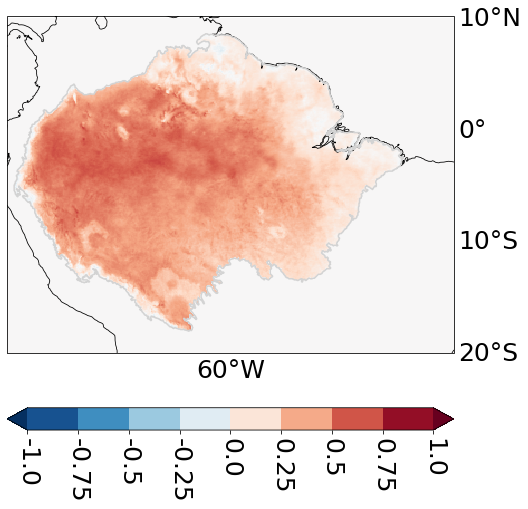

In [27]:
contourf(tas_def_absdiff_sum-tas_ctl_absdiff_sum, -1, 1, 'RdBu_r', 9, 'both', '')

In [29]:
a = tas_def_absdiff_sum-tas_ctl_absdiff_sum
a.median(dim=('lat', 'lon')).values

array(0., dtype=float32)

## PDF of the difference

In [31]:
# diff(T(i+1)-T(i))
tas_ctl_2020_diff = tas_ctl_mask_2020_day.diff(dim="time")
tas_def_2020_diff = tas_def_mask_2020_day.diff(dim="time")

In [32]:
tas_ctl_2021_diff = tas_ctl_mask_2021_day.diff(dim="time")
tas_def_2021_diff = tas_def_mask_2021_day.diff(dim="time")

In [33]:
tas_ctl_2022_diff = tas_ctl_mask_2022_day.diff(dim="time")
tas_def_2022_diff = tas_def_mask_2022_day.diff(dim="time")

In [35]:
xarray_names = ['tas_ctl_2020_diff','tas_def_2020_diff']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/distributed/client.py:3157: UserWarning: Sending large graph of size 12.62 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/distributed/client.py:3157: UserWarning: Sending large graph of size 13.36 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


In [36]:
xarray_names = ['tas_ctl_2021_diff','tas_def_2021_diff']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/distributed/client.py:3157: UserWarning: Sending large graph of size 14.00 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/distributed/client.py:3157: UserWarning: Sending large graph of size 13.90 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


In [37]:
xarray_names = ['tas_ctl_2022_diff','tas_def_2022_diff']
new_suffix = '_f'

for name in xarray_names:
    xarray_data = globals()[name]
    xarray_data_flat = xarray_data.values.flatten()
    xarray_data_flat[xarray_data_flat == 0] = np.nan
    xarray_data_f = xarray_data_flat[~np.isnan(xarray_data_flat)]
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_f

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/distributed/client.py:3157: UserWarning: Sending large graph of size 13.88 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/distributed/client.py:3157: UserWarning: Sending large graph of size 13.85 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


In [38]:
tas_ctl_diff = np.concatenate((tas_ctl_2020_diff_f, tas_ctl_2021_diff_f, tas_ctl_2022_diff_f))
tas_def_diff = np.concatenate((tas_def_2020_diff_f, tas_def_2021_diff_f, tas_def_2022_diff_f))

In [134]:
indices_ctl1 = ((bin_centers_ctl_max >= -3) & (bin_centers_ctl_max <= 3))
indices_def1 = ((bin_centers_def_max >= -3) & (bin_centers_def_max <= 3))

ctl_select = pdf_ctl_max[indices_ctl1]
def_select = pdf_def_max[indices_def1]

In [139]:
percentage_diff = (def_select - ctl_select) / ctl_select * 100

In [140]:
percentage_diff

array([ 509.20916059,  511.69026734,  538.35000877,  541.31674226,
        542.94360979,  552.46135843,  549.17786429,  539.10794729,
        523.88329426,  496.08848808,  472.03995741,  445.66658793,
        409.69897814,  374.22278499,  334.02260401,  291.62398614,
        252.17853534,  211.67242859,  172.83371298,  135.81186018,
        103.08642691,   74.68735926,   49.7928375 ,   29.08362853,
         11.81018689,   -2.25858096,  -13.51124474,  -22.25404411,
        -28.75396683,  -33.37774166,  -36.71233454,  -38.49218595,
        -38.9893071 ,  -38.49211624,  -36.97262863,  -34.6512664 ,
        -31.39788046,  -27.12822051,  -21.4486244 ,  -14.15474516,
         -4.39836415,    8.39166888,   24.31301685,   45.00967125,
         71.38897534,  103.86046552,  145.48626472,  194.16264182,
        254.62350952,  319.81481545,  393.75820742,  475.40391199,
        549.79015488,  622.00888054,  680.44704243,  744.39279315,
        818.05341684,  896.73645769,  960.41332498, 1034.53472

/tmp/ipykernel_2566453/3315536721.py:10: RuntimeWarning: divide by zero encountered in true_divide
  pct_change = np.where(pdf_ctl_max != 0, (pdf_def_max - pdf_ctl_max) / pdf_ctl_max * 100, 0)
/tmp/ipykernel_2566453/3315536721.py:10: RuntimeWarning: invalid value encountered in true_divide
  pct_change = np.where(pdf_ctl_max != 0, (pdf_def_max - pdf_ctl_max) / pdf_ctl_max * 100, 0)


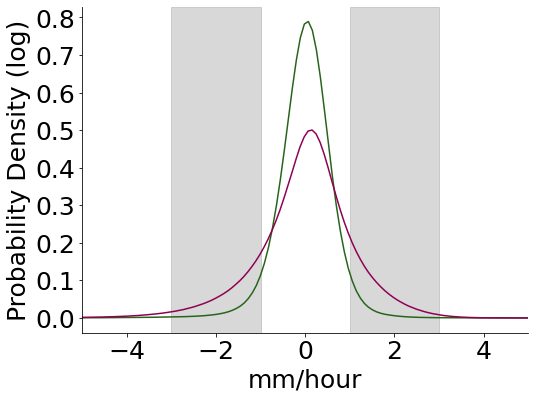

In [ ]:
# Normalize the PDF
pdf_ctl_max, bins_ctl_max = np.histogram(tas_ctl_diff, bins=250, density=True)  # Adjust the number of bins as needed (hist, bins)
pdf_def_max, bins_def_max = np.histogram(tas_def_diff, bins=250, density=True)  # Adjust the number of bins as needed

# Calculate the bin centers
bin_centers_ctl_max = (bins_ctl_max[:-1] + bins_ctl_max[1:]) * 0.5
bin_centers_def_max = (bins_def_max[:-1] + bins_def_max[1:]) * 0.5

# in percentage
pct_change = np.where(pdf_ctl_max != 0, (pdf_def_max - pdf_ctl_max) / pdf_ctl_max * 100, 0)

# Plot the PDF
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

fig = plt.figure(figsize=(8, 6))
plt.plot(bin_centers_ctl_max, pdf_ctl_max, label='CTL_max', color=right, linewidth=1.5)
plt.plot(bin_centers_def_max, pdf_def_max, label='DEF_max', color=left, linewidth=1.5)

# Set labels and title
plt.xlabel('mm/hour', fontsize='25')
plt.ylabel('Probability Density (log)', fontsize='25')
#plt.title('PDF', fontsize='15')
#plt.yscale('log')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
#plt.xscale('log')
#
plt.xlim(-5, 5)
# remove frame on upper and right side
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# add legend
#plt.legend(fontsize=15)
plt.axvspan(-3, -1, color='gray', alpha=0.3)
plt.axvspan(1, 3, color='gray', alpha=0.3)
# Display the plot
plt.show()

/tmp/ipykernel_1307741/3219254153.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('PiYG')


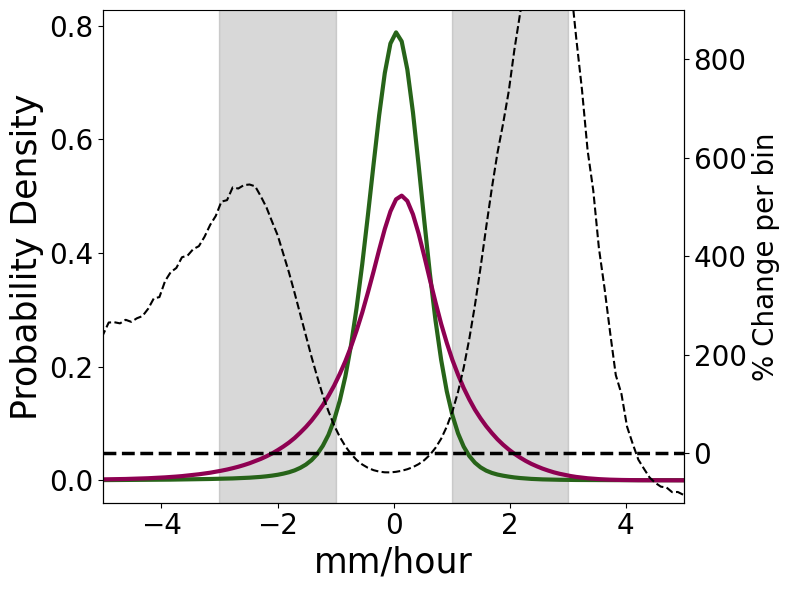

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Define shared bins (min/max of both datasets)
shared_bins = np.histogram_bin_edges(np.concatenate([tas_ctl_diff, tas_def_diff]), bins=250)

# Use the shared bins for both PDFs
pdf_ctl_max, _ = np.histogram(tas_ctl_diff, bins=shared_bins, density=True)
pdf_def_max, _ = np.histogram(tas_def_diff, bins=shared_bins, density=True)

# Bin centers
bin_centers = (shared_bins[:-1] + shared_bins[1:]) * 0.5

# Percent change per bin
with np.errstate(divide='ignore', invalid='ignore'):
    percent_change = (pdf_def_max - pdf_ctl_max) / pdf_ctl_max * 100
    percent_change = np.where(pdf_ctl_max == 0, np.nan, percent_change)

cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

# Plot
fig, ax1 = plt.subplots(figsize=(8, 6))

# Main PDFs
ax1.plot(bin_centers, pdf_ctl_max, label='CTL_max', color=right, linewidth=3.0)
ax1.plot(bin_centers, pdf_def_max, label='DEF_max', color=left, linewidth=3.0)
ax1.set_xlabel('mm/hour', fontsize=25)
ax1.set_ylabel('Probability Density', fontsize=25)
ax1.tick_params(axis='both', labelsize=20)
ax1.set_xlim(-5, 5)
ax1.axvspan(-3, -1, color='gray', alpha=0.3)
ax1.axvspan(1, 3, color='gray', alpha=0.3)
ax1.spines['top'].set_visible(False)

# Right y-axis for percent change
ax2 = ax1.twinx()
ax2.plot(bin_centers, percent_change, color='black', linestyle='--', label='% Change per bin')

# only for the regions of interest
#ax2.plot(bin_centers[(bin_centers >= -3) & (bin_centers <= -1)], 
#         percent_change[(bin_centers >= -3) & (bin_centers <= -1)], 
#         color='black', linestyle='--', linewidth=1.5)

# Right region (1 to 3)
#ax2.plot(bin_centers[(bin_centers >= 1) & (bin_centers <= 3)], 
#         percent_change[(bin_centers >= 1) & (bin_centers <= 3)], 
#         color='black', linestyle='--', linewidth=1.5)
ax2.set_ylabel('% Change per bin', fontsize=20)
ax2.tick_params(axis='y', labelsize=20)
ax2.set_ylim(-100, 900)
ax2.axhline(0, color='black', linewidth=2.5, linestyle='--')  # horizontal reference line


# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
#ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=15)

plt.tight_layout()
plt.show()


In [152]:
tas_ctl_diff

array([-0.3494873 , -0.61364746, -0.41574097, ...,  0.46017456,
        0.10415649,  0.39068604], dtype=float32)

In [154]:
percent_change[(bin_centers >= -3) & (bin_centers <= -1)].mean()

388.80905910664706

In [155]:
percent_change[(bin_centers >= 1) & (bin_centers <= 3)].mean()

738.3533022448579